In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from google.colab import files
import io

In [2]:
df=pd.read_csv('/content/Loan_Default.csv')
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [3]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [5]:
df.isnull().sum()

,0
ID,0
year,0
loan_limit,3344
Gender,0
approv_in_adv,908
loan_type,0
loan_purpose,134
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


In [6]:
df.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')

In [7]:
replace_dicts = {
    'loan_limit': {'cf': 'Conforming', 'ncf': 'Non-Conforming'},
    'approv_in_adv': {'nopre': 'Not pre-approved', 'pre': 'Pre-approved'},
    'Credit_Worthiness': {'l1': 'Low', 'l2': 'High'},
    'Gender': {'m': 'Male', 'f': 'Female', 'joint': 'Joint'},
    'business_or_commercial': {'na': 'Not Business', 'y': 'Business'},
    'Neg_ammortization': {'not_neg': 'Not Negative', 'neg': 'Negative'}
}

In [8]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [9]:
for col, mapping in replace_dicts.items():
    if col in df.columns:
        df[col] = df[col].replace(mapping)

In [10]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [11]:
df.isnull().sum()

,0
ID,0
year,0
loan_limit,0
Gender,0
approv_in_adv,0
loan_type,0
loan_purpose,0
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


In [12]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

df_encoded = df.copy()


categorical_cols = df_encoded.select_dtypes(include='object').columns
binary_cols = [col for col in categorical_cols if df_encoded[col].nunique() == 2]
multi_cols = [col for col in categorical_cols if df_encoded[col].nunique() > 2]

print("Binary columns:", binary_cols)
print("Multi-category columns:", multi_cols)


le = LabelEncoder()
for col in binary_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])


df_encoded = pd.get_dummies(df_encoded, columns=multi_cols, drop_first=True)

print("Encoding complete!")
print("Final shape:", df_encoded.shape)

Binary columns: ['loan_limit', 'approv_in_adv', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'construction_type', 'Secured_by', 'co-applicant_credit_type', 'submission_of_application', 'Security_Type']
Multi-category columns: ['Gender', 'loan_type', 'loan_purpose', 'occupancy_type', 'total_units', 'credit_type', 'age', 'Region']
Encoding complete!
Final shape: (148670, 51)


In [13]:
df['loan_to_income_ratio'] = df['loan_amount'] / (df['income'] + 1)

In [14]:
df['LTV_percent'] = (df['loan_amount'] / (df['property_value'] + 1)) * 100

In [15]:
df['high_risk'] = np.where(df['Credit_Worthiness'] == 'Low', 1, 0)

In [35]:
df['DTI_Category'] = pd.cut(
    df['dtir1'],
    bins=[0, 20, 35, 50, 100],
    labels=['Low DTI', 'Moderate DTI', 'High DTI', 'Extreme DTI']
)
# Encode DTI_Category
dti_map = {
    'Low DTI': 0,
    'Moderate DTI': 1,
    'High DTI': 2,
    'Extreme DTI': 3
}

df['DTI_Category'] = df['DTI_Category'].map(dti_map).astype(float)

In [17]:
df['interest_burden'] = (df['rate_of_interest'] * df['loan_amount']) / (df['income'] + 1)

In [18]:
df['long_term_flag'] = np.where(df['term'] >= 240, 1, 0)

In [19]:
df['upfront_charge_percent'] = (df['Upfront_charges'] / (df['loan_amount'] + 1)) * 100

In [20]:
risk_map = {
    'Type1': 1,
    'Type2': 2,
    'Type3': 3
}
if 'loan_type' in df.columns:
    df['loan_type_risk'] = df['loan_type'].map(risk_map)


In [21]:
df['approval_readiness_score'] = (
    (df['approv_in_adv'].apply(lambda x: 1 if x == 'Pre-Approved' else 0)) +
    (df['Credit_Worthiness'].apply(lambda x: 1 if x == 'High' else 0)) +
    (df['income'] / df['income'].max())
)

In [22]:
if 'Region' in df.columns:
    region_density = df['Region'].value_counts().to_dict()
    df['region_loan_density'] = df['Region'].map(region_density)

In [23]:
# Credit score bands — industry standard, highly predictive
df['credit_band'] = pd.cut(df['Credit_Score'],
                    bins=[0, 580, 670, 740, 800, 850],
                    labels=['poor', 'fair', 'good', 'very_good', 'exceptional'])

# Co-applicant flag — unused column with real signal
df['has_coapplicant'] = (
    df['co-applicant_credit_type'] != 'not_applicable'
).astype(int)

In [24]:
df[['loan_to_income_ratio', 'LTV_percent', 'high_risk', 'interest_burden','credit_band','has_coapplicant','approval_readiness_score']].head()

,loan_to_income_ratio,LTV_percent,high_risk,interest_burden,credit_band,has_coapplicant,approval_readiness_score
0,66.915566,98.727977,1,266.993107,very_good,1,0.003007
1,41.457539,49.401796,1,165.415579,poor,1,0.008607
2,42.875224,80.019528,1,195.511022,exceptional,1,0.016385
3,38.422692,69.376794,1,163.296440,fair,1,0.020533
4,66.708170,91.886422,1,266.832679,fair,1,0.018044


In [25]:
df['emi_to_income_ratio'] = (df['rate_of_interest'] * df['loan_amount']) / (df['income'] + 1)
df['upfront_charge_percent'] = (df['Upfront_charges'] / (df['loan_amount'] + 1)) * 100
df['long_term_flag'] = np.where(df['term'] >= 240, 1, 0)

In [59]:
features=[
    'loan_to_income_ratio',      # affordability
    'LTV_percent',               # your recalculated LTV — more reliable
    'interest_burden',           # rate × loan / income
    'upfront_charge_percent',    # loan structure signal
    'long_term_flag',            # binary duration flag
    'emi_to_income_ratio',
    'high_risk',
    'approval_readiness_score',
    'DTI_Category',
]
X = df[features]
y = df['Status']

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [61]:
from imblearn.over_sampling import SMOTE
# Apply SMOTE ONLY on training data
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
#from imblearn.combine import SMOTETomek

#smt = SMOTETomek(random_state=42)
#X_resampled, y_resampled = smt.fit_resample(X_train, y_train)

In [62]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_resampled, y_resampled)
y_pred = model.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

y_probs = model.predict_proba(X_test)[:,1]
print("ROC AUC:", roc_auc_score(y_test, y_probs))

[[21430   976]
 [  479  6849]]
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     22406
           1       0.88      0.93      0.90      7328

    accuracy                           0.95     29734
   macro avg       0.93      0.95      0.94     29734
weighted avg       0.95      0.95      0.95     29734

ROC AUC: 0.9895173015639916


              precision    recall  f1-score   support

           0       0.99      0.93      0.96     22406
           1       0.82      0.96      0.88      7328

    accuracy                           0.94     29734
   macro avg       0.90      0.94      0.92     29734
weighted avg       0.94      0.94      0.94     29734

ROC AUC: 0.9876499721349202

✅ FINAL MODEL PERFORMANCE (with new features + SMOTE):
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     22406
           1       0.82      0.96      0.88      7328

    accuracy                           0.94     29734
   macro avg       0.90      0.94      0.92     29734
weighted avg       0.94      0.94      0.94     29734



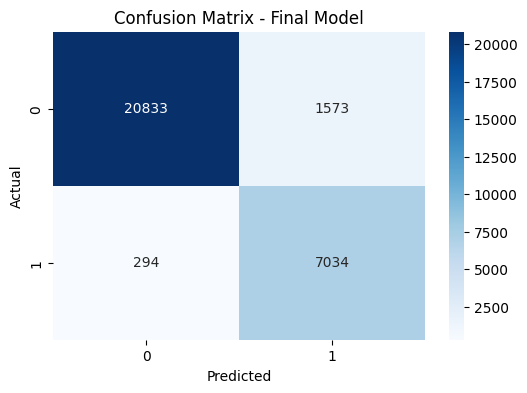

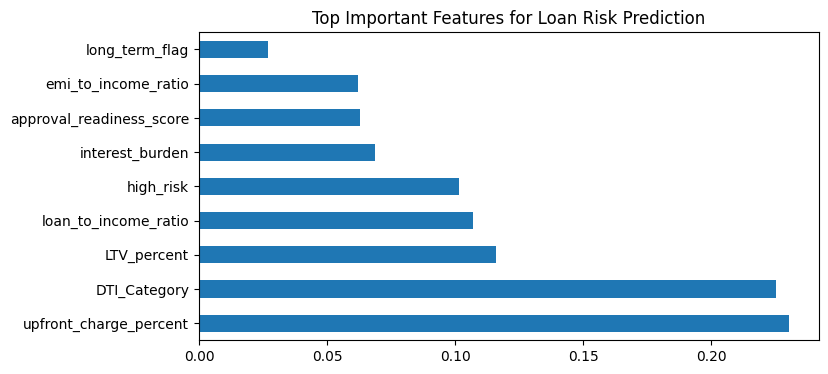

In [63]:
from xgboost import XGBClassifier

final_model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

final_model.fit(X_resampled, y_resampled)

y_pred = final_model.predict(X_test)

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))

y_probs = final_model.predict_proba(X_test)[:,1]
print("ROC AUC:", roc_auc_score(y_test, y_probs))

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = final_model.predict(X_test)

print("\n✅ FINAL MODEL PERFORMANCE (with new features + SMOTE):")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Final Model')
plt.show()

import pandas as pd

importance = pd.Series(final_model.feature_importances_, index=features)
importance.nlargest(10).plot(kind='barh', figsize=(8,4))
plt.title("Top Important Features for Loan Risk Prediction")
plt.show()

In [64]:
import joblib

joblib.dump(final_model, "loan_risk_model.joblib")
df.to_csv("final_dataset.csv", index=False)

print("Final model and dataset saved successfully!")
print("Model File: final_loan_model.joblib")
print("Dataset File: final_loan_dataset.csv")

Final model and dataset saved successfully!
Model File: final_loan_model.joblib
Dataset File: final_loan_dataset.csv


In [69]:
import joblib
import numpy as np
import pandas as pd

model= joblib.load('loan_risk_model.joblib')
sample = {
    "income": 50000,
    "loan_amount": 200000,
    "property_value": 300000,
    "rate_of_interest": 8.5,
    "Upfront_charges": 1500,
    "term": 240,
    "Credit_Worthiness": "Low",
    "approv_in_adv": "Pre-Approved",
    "dtir1": 30
}
# Create feature values based on engineered features
loan_to_income_ratio = sample["loan_amount"] / (sample["income"] + 1)
LTV_percent = (sample["loan_amount"] / (sample["property_value"] + 1)) * 100
interest_burden = (sample["rate_of_interest"] * sample["loan_amount"]) / (sample["income"] + 1)
upfront_charge_percent = (sample["Upfront_charges"] / (sample["loan_amount"] + 1)) * 100
long_term_flag = 1 if sample["term"] >= 240 else 0
high_risk = 1 if sample["Credit_Worthiness"] == "Low" else 0
emi_to_income_ratio = interest_burden / 10
approval_readiness_score = (
    (1 if sample["approv_in_adv"] == "Pre-Approved" else 0) +
    (1 if sample["Credit_Worthiness"] == "High" else 0) +
    (sample["income"] / 100000)   # normalize income
)
dtir = sample["dtir1"]
if dtir <= 20:
    dti_cat = 0
elif dtir <= 35:
    dti_cat = 1
elif dtir <= 50:
    dti_cat = 2
else:
    dti_cat = 3

# Define the features list in the correct order as used during training
# This list should match the `features` variable used in cell pUpIF3cfYJKn
features_order = [
    'loan_to_income_ratio',
    'LTV_percent',
    'interest_burden',
    'upfront_charge_percent',
    'long_term_flag',
    'emi_to_income_ratio',
    'high_risk',
    'approval_readiness_score',
    'DTI_Category'
]

# Create DataFrame with SAME feature names and in the CORRECT order
X_new_data = {
    'loan_to_income_ratio': loan_to_income_ratio,
    'LTV_percent': LTV_percent,
    'interest_burden': interest_burden,
    'upfront_charge_percent': upfront_charge_percent,
    'long_term_flag': long_term_flag,
    'emi_to_income_ratio': emi_to_income_ratio, # Corrected order
    'high_risk': high_risk, # Corrected order
    'approval_readiness_score': approval_readiness_score,
    'DTI_Category': dti_cat, # Use dti_cat here
}
X_new = pd.DataFrame([X_new_data])
X_new = X_new[features_order] # Ensure the order matches the model's expectation

# -------- Prediction --------
prediction = model.predict(X_new)
probability = model.predict_proba(X_new)[0][1]
# -------- Output --------
if prediction[0] == 1:
    print("Prediction: Default (High chance borrower will NOT repay loan)")
else:
    print("Prediction: No Default (Borrower likely to repay loan)")

print("Default Probability:", probability)

# -------- Loan Decision --------
if probability < 0.30:
    print("Loan Status: Approved")
elif probability < 0.60:
    print("Loan Status: Approved with Conditions")
else:
    print("Loan Status: Rejected")


Prediction: No Default (Borrower likely to repay loan)
Default Probability: 0.23814668
Loan Status: Approved
